# Statistics II Practice – Project Cycle 1
Exploratory Data Analysis Workflow (Diabetes.csv)

## Overview

This notebook is the required template for **Project Cycle 1**.

This notebook has been completed with the required code, plots, and interpretations.
- Use **matplotlib** for plotting in required sections.
- Keep the notebook **runnable from top to bottom**.
- Work as a **group** and make sure every member understands the notebook.

Project question (Cycle 1):
**Which characteristics appear related to diabetes (Outcome) in this dataset?**

**Ans:**
In this dataset, diabetes (Outcome=1) is most clearly related to higher Glucose, and it also tends to be higher for people with higher BMI. The diabetes rate increases a lot as Glucose and BMI move from low to high groups.


## 0. Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 13
np.random.seed(SEED)


## 1. Load and Inspect the Dataset

Required file: `Diabetes.csv`

Completed tasks:
1) Load the CSV into a DataFrame named `df`  
2) Display the first 5 rows  
3) Report: number of rows, number of columns  
4) Check data types  


In [12]:
# TO DO: load dataset (hint: pd.read_csv)
df = pd.read_csv("Diabetes.csv")

# Preview first 5 rows
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
# TO DO: show dataset shape (rows, columns)
df.shape

(768, 9)

In [14]:
# TO DO: inspect data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Interpretation (3–5 lines):

- Q1: How many observations and variables? A1: Based on **"df.shape"**, we can see that the dataset contains **768 observations** and **9 variables**.
  
- Q2: What is the outcome variable? A2: The outcome variable is Outcome, where **0 = no diabetes** and **1 = diabetes.**.

- Q3: What types of variables do you see (continuous vs discrete/binary)?

- A3: Based on **df.info()**, Glucose , BloodPressure , SkinThickness , Insulin , BMI , DiabetesPedigreeFunction , Age can be treated as continuous variables. Pregnancies can be treated as discrete variables. Outcome is a binary variable because it only takes 0 and 1.

## 2. Data Quality Checks

Completed tasks:
- Compute summary statistics
- Check missing values
- Check suspicious zeros in selected medical variables

In [15]:
# TO DO: summary statistics (hint: df.describe())
summary = df.describe()
summary

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [16]:
# TO DO: missing values count (hint: df.isna().sum())
missing_counts = df.isna().sum()
missing_counts

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [17]:
# TO DO (optional): count how many zeros appear in selected variables
# Why? In some datasets, 0 may represent 'missing' for measurements.

vars_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] #因為這五個變數不可能為0，而其他(ex:懷孕、年齡、糖尿病譜系功能及結果)可以為0
zero_counts = (df[vars_to_check] == 0).sum()
zero_counts

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Interpretation (5–8 lines):

- Q1: Are there missing values? A1: Based on **missing_counts**, there are no formal missing values detected in the dataset.

- Q2: Which variables have suspicious values? A2: Based on **"zero_counts"**, Insulin (374 zeros) and SkinThickness (227 zeros) contain many zero values, which are unlikely to be realistic in all cases. BloodPressure (35 zeros), BMI (11 zeros), and Glucose (5 zeros) also include questionable zeros.

- Q3: What might those suspicious values mean for analysis (e.g., missing coded as 0)? A3: This suggests that the dataset is complete in structure, but not necessarily complete in measurement quality. These suspicious values should be kept in mind when interpreting plots and comparing groups.

## 3. Required Visualizations (Matplotlib Default)

You must produce the following plots using **matplotlib**:

A) Histogram of Glucose  
B) Histogram of BMI  
C) Boxplot of Glucose by Outcome  
D) Scatter: Age vs BMI (use color/marker by Outcome)

After each plot, write a short interpretation (2–4 lines).


### 3A. Histogram of Glucose

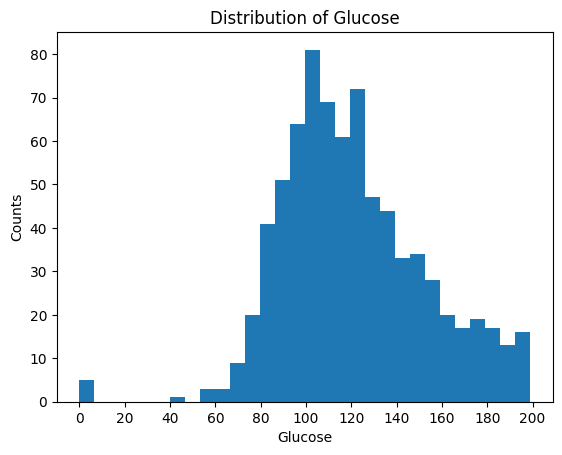

np.float64(31.97261819513622)

In [18]:
plt.figure()

# TO DO: histogram of Glucose (hint: plt.hist)
# Use 30 bins.

plt.hist(df["Glucose"], bins=30)
plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Counts")
plt.xticks(np.arange(0, 201, 20))
plt.show()

spread = df["Glucose"].std(ddof=1)
spread

Interpretation (Describe shape, center, spread, and any unusual features/outliers.) :

- The Glucose distribution is **unimodal** and slightly **right-skewed**.  
- Its center appears to be around **100–120**, with substantial spread across the sample.  
- Most values are concentrated in the middle range, but a few unusually low values near 0 may be unrealistic or indicate possible data quality issues.
- There are also some relatively high glucose values, although no extreme outliers are clearly separated from the rest.

### 3B. Histogram of BMI

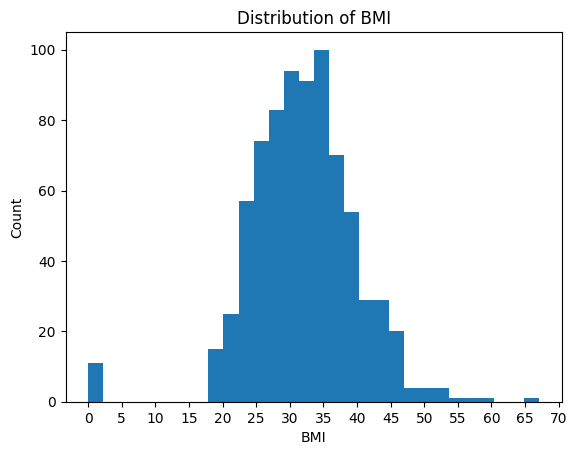

In [19]:
plt.figure()

# TO DO: histogram of BMI (hint: plt.hist)
# Use 30 bins.

plt.hist(df["BMI"], bins=30)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.xticks(np.arange(0, 71, 5))
plt.show()

Interpretation (Describe shape, center, spread, and any unusual features/outliers.) :

- The BMI distribution is also **unimodal** and slightly **right-skewed**.  
- Most observations cluster around **30-35**.
- Most values are concentrated in the middle range, but a few unusually low values near 0 may be unrealistic or indicate possible data quality issues.
- Some large BMI values extend the right tail, but the overall distribution still looks reasonably concentrated.

### 3C. Boxplot: Glucose by Outcome

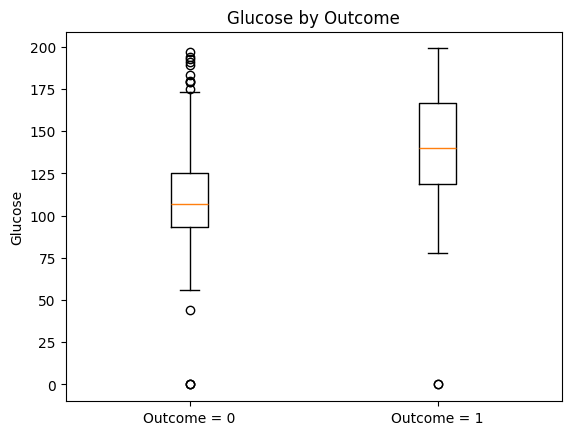

In [20]:
# TO DO: create two groups of Glucose values by Outcome
g0 = df.loc[df["Outcome"] == 0, "Glucose"]
g1 = df.loc[df["Outcome"] == 1, "Glucose"]

plt.figure()

# TO DO: boxplot comparing the two groups (hint: plt.boxplot)
# labels should be ["Outcome=0", "Outcome=1"]

plt.boxplot([g0, g1], tick_labels=["Outcome = 0", "Outcome = 1"])
plt.title("Glucose by Outcome")
plt.ylabel("Glucose")
plt.show()

Interpretation (Compare medians and variability. Do the groups appear separated?):

- The median Glucose level for **Outcome = 1** is clearly higher than for **Outcome = 0**.  
- The diabetes group also appears to have somewhat greater spread.  
- Although the two groups overlap, the boxplots show a separation in their centers.
- This suggests that Glucose is strongly associated with Outcome.
- Some high values also appear in Outcome = 0, which means Glucose is an important variable but not a perfect separator by itself.

### 3D. Scatter: Age vs BMI (by Outcome)

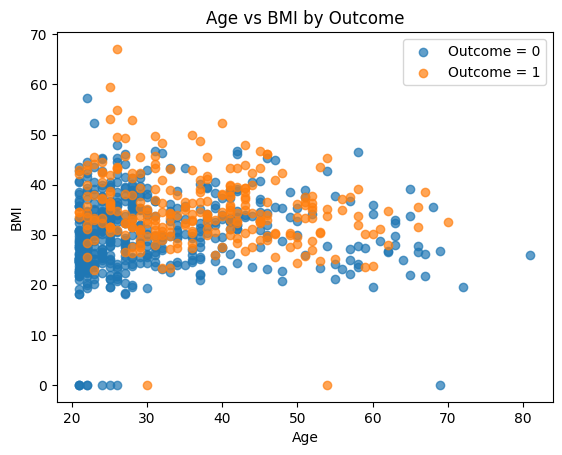

In [21]:
# TO DO: split dataset by Outcome
df0 = df[df["Outcome"] == 0]
df1 = df[df["Outcome"] == 1]

plt.figure()

# TO DO: scatter plots for the two groups (hint: plt.scatter)
# Use alpha=0.7 and include labels.

plt.scatter(df0["Age"], df0["BMI"], alpha=0.7, label="Outcome = 0")
plt.scatter(df1["Age"], df1["BMI"], alpha=0.7, label="Outcome = 1")
plt.title("Age vs BMI by Outcome")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend()
plt.show()

Interpretation (Do you see clustering or separation between groups?):

- There is some overlap between the two groups, so the separation is not perfect.  
- However, observations with **higher BMI** and **older age** seem more common in the **Outcome = 1** group.  
- The Outcome = 1 group appears more frequently among observations with BMI above 30.
- This suggests that **Age** and **BMI** may both be related to Outcome, though not as strongly as Glucose.
- A few points with BMI near 0 also appear, which may reflect possible data quality issues.

## 4. Group Comparison Summary (Descriptive)

Completed tasks:
1) Compute group means for Glucose, BMI, Age by Outcome  
2) Compute mean differences (Outcome=1 minus Outcome=0)  


In [22]:
# TO DO: group means table (hint: groupby + mean)
summary_means = df.groupby("Outcome")[["Glucose", "BMI", "Age"]].mean()
summary_means

,Glucose,BMI,Age
Outcome,,,
0,109.980000,30.304200,31.190000
1,141.257463,35.142537,37.067164


In [23]:
# TO DO: compute mean differences (Outcome=1 minus Outcome=0)
# hint: summary_means.loc[1] - summary_means.loc[0]
mean_diff = summary_means.loc[1] - summary_means.loc[0]
mean_diff.sort_values(ascending=False)

Glucose    31.277463
Age         5.877164
BMI         4.838337
dtype: float64

Interpretation (5–8 lines):

- The Outcome = 1 group has higher mean values for Glucose, BMI, and Age than the Outcome = 0 group.
- Among these three variables, Glucose shows the largest mean difference between the two groups.
- Age and BMI also show positive mean differences, but they are smaller than that of Glucose.
- This descriptive comparison suggests that these variables may be associated with Outcome, especially Glucose.
- Although a larger mean difference suggests a stronger descriptive contrast between the two groups, it does not by itself prove a stronger relationship.

## 5. Sampling Simulation (Concept Preparation)

Goal: understand sampling variability of the sample mean.

Completed tasks:
1) Sample n = 30 observations (with replacement)  
2) Compute the sample mean of Glucose  
3) Repeat B = 1000 times  
4) Plot the distribution of sample means (matplotlib)  
5) Report the mean and standard deviation of the sampling distribution  


In [24]:
# TO DO: set simulation parameters
B = 1000
n = 30

In [25]:
means = []

for b in range(B):
    # TO DO: draw a bootstrap sample of size n (with replacement)
    sample = df.sample(n=n, replace=True) # hint: df.sample

    # TO DO: compute mean of Glucose in this sample
    m = sample["Glucose"].mean()

    means.append(m)

means = np.array(means)

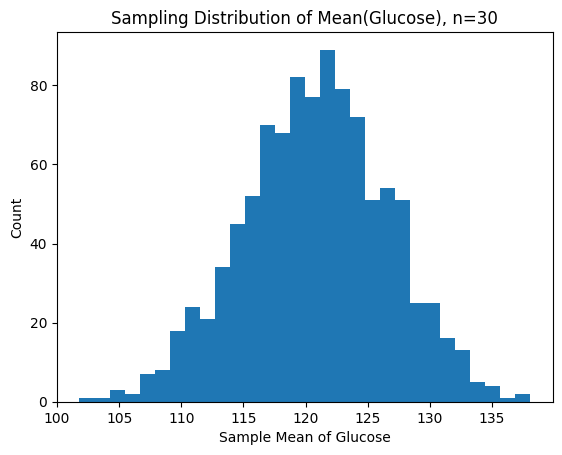

In [26]:
plt.figure()

# TO DO: histogram of simulated sample means (hint: plt.hist)

plt.hist(means, bins=30)
plt.title("Sampling Distribution of Mean(Glucose), n=30")
plt.xlabel("Sample Mean of Glucose")
plt.ylabel("Count")
plt.show()

In [27]:
# TO DO: report center and spread of the sampling distribution
# hint: means.mean() and means.std(ddof=1)
center = means.mean()
spread = means.std(ddof=1)

center, spread

(np.float64(120.82436666666666), np.float64(5.821433272906807))

Interpretation (5–8 lines):

- Q1: What does the sampling distribution represent? A1: This sampling distribution represents the distribution of the **sample mean of Glucose** over many repeated samples of size **30**.
- Q2: Is it narrower than the raw Glucose distribution? Why? A2: The sampling distribution is **much narrower** than the raw Glucose distribution. This happens because sample means vary less than individual observations. In other words, averaging reduces random fluctuation.
- Q3: How does this connect to uncertainty of an estimate? A3: The spread of the sampling distribution shows how much the sample mean changes from sample to sample. A smaller spread means the estimate is more stable and has less uncertainty.

## Week B Consultation Checklist (Must Be Completed Before Consultation)

Before Week B, your group must have a **runnable draft** that includes:

1) Sections 1–5 completed (code runs without errors)  
2) All required plots (3A–3D) displayed correctly  
3) Group summary table (Section 4) + a short conclusion paragraph  
4) Sampling simulation completed (Section 5) + interpretation  
5) A proposed extension idea for Week C (next section)

No runnable draft → no Week B consultation mark.


## 6. Week C Extension

Choose **one** extension direction. The extension should add insight beyond the required analysis.

Examples (choose one):
- Correlation analysis (heatmap or top correlations with Outcome)
- Compare medians instead of means (robustness)
- Create age groups and compare outcomes across age bins
- Create BMI categories and compare outcome rates
- Another visualization (density, pairwise, etc.)

Write your plan first, then implement below.


### 6A. Extension Plan (5–8 lines)

We extend the analysis by examining how the diabetes rate changes across balanced age groups. **Rather than using unequal age ranges, we divide Age into four quantile-based groups so that each group has a similar sample size. Younger observations are more concentrated, whereas older observations are more dispersed.** For each group, we compute the mean of Outcome, which can be interpreted as the sample proportion of diabetes cases. To make the comparison more informative, we also calculate the standard error of each proportion. This allows us to compare not only the diabetes rates themselves, but also how stable each estimate is under sampling variability. **Finally, we visualize the diabetes rates with approximate error bars based on plus or minus two standard errors, so that the age-related trend and the stability of each estimate can be seen more clearly.**

我們進一步分析糖尿病發生率在平衡年齡層間的變化。**我們不使用不等的年齡範圍，而是將年齡分成四個分位數小組，使每組樣本數相近。較年輕的觀察較為集中，較年長的觀察則較為分散**。對每個群組，我們計算結果的平均值，可解釋為糖尿病病例的樣本比例。為了讓比較更具參考價值，我們也計算了每個比例的標準誤。這讓我們不僅能比較糖尿病發病率本身，也能比較每個估計值在抽樣變異性下的穩定性。**最後，我們以正負兩個標準誤差的近似誤差條來視覺化糖尿病發病率，以便更清楚看到與年齡相關的趨勢及每個估計值的穩定性。**

### 6B. Extension Implementation (code + outputs)

0.25    24.0
0.50    29.0
0.75    41.0
1.00    81.0
Name: Age, dtype: float64 
---------------------------------------------------------------------------------------------------
Min age = 21 , count(age <= 20) = 0 .No observations under the age of 20 were included. 
---------------------------------------------------------------------------------------------------


,AgeGroupQ,Count,DiabetesCases,DiabetesRate,SE,Lower,Upper
0,G1: 21–24,219,31,0.141553,0.023556,0.094441,0.188664
1,G2: 25–29,177,53,0.299435,0.034426,0.230583,0.368287
2,G3: 30–41,200,95,0.475000,0.035311,0.404378,0.545622
3,G4: 42–81,172,89,0.517442,0.038101,0.441239,0.593645


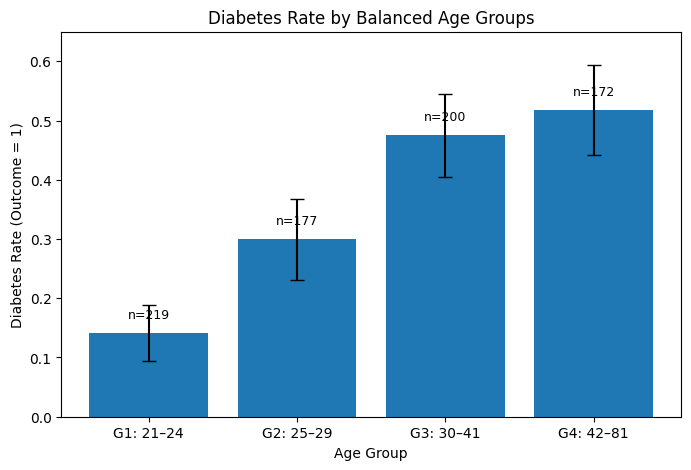

In [40]:
# Extension: diabetes rate by balanced age groups (quartiles)

df_ext = df.copy()

#求四分位數
print(df["Age"].quantile([0.25, 0.50, 0.75, 1.00]), "\n---------------------------------------------------------------------------------------------------")

# Create 4 age groups with similar sample sizes
df_ext["AgeGroupQ"] = pd.qcut(  #先把 Age由小到大排序，再依照分位數切成4份，讓每一份的樣本數盡量接近
    df_ext["Age"],
    4,
    labels=["G1: 21–24", "G2: 25–29", "G3: 30–41", "G4: 42–81"]
)

# Summarize each group
age_summary = df_ext.groupby("AgeGroupQ", observed=False)["Outcome"].agg(
    Count="count",
    DiabetesCases="sum",
    DiabetesRate="mean"
).reset_index()

# Plug-in standard error for sample proportion
age_summary["SE"] = np.sqrt(
    age_summary["DiabetesRate"] * (1 - age_summary["DiabetesRate"]) / age_summary["Count"]
)

# Approximate error band: rate ± 2SE
age_summary["Lower"] = np.clip(age_summary["DiabetesRate"] - 2 * age_summary["SE"], 0, 1)
age_summary["Upper"] = np.clip(age_summary["DiabetesRate"] + 2 * age_summary["SE"], 0, 1)

#沒有20歲(含)以下的樣本
print("Min age =", df["Age"].min(), ", count(age <= 20) =", (df["Age"] <= 20).sum(), ".No observations under the age of 20 were included.", "\n---------------------------------------------------------------------------------------------------") 
display(age_summary)

# Plot
x = np.arange(len(age_summary))
rates = age_summary["DiabetesRate"].values
err_low = rates - age_summary["Lower"].values
err_high = age_summary["Upper"].values - rates

plt.figure(figsize=(8,5))
plt.bar(x, rates, yerr=[err_low, err_high], capsize=5)
plt.xticks(x, age_summary["AgeGroupQ"])
plt.ylim(0, 0.65)
plt.xlabel("Age Group")
plt.ylabel("Diabetes Rate (Outcome = 1)")
plt.title("Diabetes Rate by Balanced Age Groups")

for i, row in age_summary.iterrows():
    plt.text(i, row["DiabetesRate"] + 0.025,
             f'n={int(row["Count"])}',
             ha='center', fontsize=9)
    
plt.show()

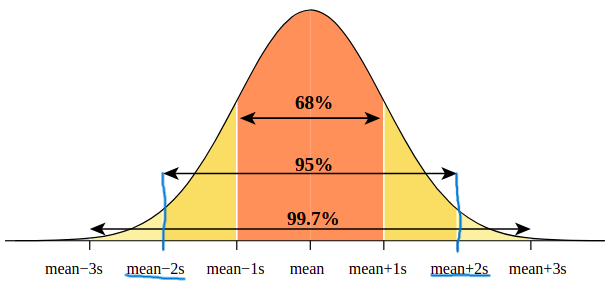

### 6C. Extension Interpretation (5–8 lines)

The diabetes rate increases clearly across the four balanced age groups, from 14.2% in G1 (21–24) to 29.9% in G2 (25–29), 47.5% in G3 (30–41), and 51.7% in G4 (42–81). This upward pattern suggests that diabetes prevalence tends to rise with age in this dataset. Because the age groups were formed by quantiles, the sample sizes are relatively balanced, which makes the comparison more stable across groups. The approximate error bars based on plus or minus two standard errors are fairly narrow, so the observed increasing pattern is unlikely to be explained only by sampling fluctuation. In addition, the dataset contains no observations under age 20, so the interpretation should be limited to the age range actually observed in the sample. Overall, Age appears to be a useful variable for understanding how diabetes prevalence changes across different age groups.

糖尿病發生率在四個平衡年齡組中明顯上升，從第一組（21–24 歲） 的 14.2% 升至第二組（25–29 歲） 的 29.9%， 第三組（30–41 歲） 為 47.5%， 第四組 （42–81 歲） 為 51.7%。 這種上升趨勢顯示，在這組數據集中，糖尿病盛行率往往隨年齡上升。由於年齡組是由分位數組成，樣本量相對平衡，使得跨組比較更穩定。基於正負兩個標準誤差的近似誤差條相當狹窄，因此觀察到的增加模式不太可能僅靠抽樣波動來解釋。此外，資料集中沒有 20 歲以下的觀察數據，因此解讀應限於樣本中實際觀察到的年齡範圍。整體而言， 年齡似乎是理解不同年齡層糖尿病盛行率變化的有用變數。

## 7. Week C Exhibition Reflection (After Rotations)

After you visit other groups during Week C, write at least **three** items:

1) One interesting analysis/visualization idea you saw  
2) One interpretation insight that was better than yours (what and why)  
3) One improvement you would apply to your own workflow next time  


Reflection notes:

1) Group/booth visited:
   - Key idea learned:
   - What was interesting or useful:

2) Group/booth visited:
   - Key idea learned:
   - What was interesting or useful:

3) Group/booth visited:
   - Key idea learned:
   - What was interesting or useful: